# Code Lab 7 - Easy OCR

<img src="https://github.com/JaidedAI/EasyOCR/raw/master/examples/easyocr_framework.jpeg">

Этот ноутбук демонстрирует все возможности оптического распознавания символов (OCR) с использованием библиотеки EasyOCR. Мы рассмотрим различные сценарии использования, визуализацию результатов и практические примеры.

## План работы:
- Распознавание текста на изображениях (русский + английский)
- Визуализация bounding boxes
- Пакетная обработка
- Работа с разными типами изображений
- Экспорт результатов

## 1. Установка зависимостей

Выполните установку необходимых библиотек:

## 2. Импорт библиотек

In [1]:
import os
import sys
import time
import json
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import easyocr

# Настройка отображения matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 3. Инициализация OCR

Создадим класс для работы с OCR с расширенными возможностями:

In [2]:
class EasyOCRDemo:
    """Класс для демонстрации возможностей OCR"""
    
    def __init__(self, languages: List[str] = ['ru', 'en'], gpu: bool = False):
        """
        Инициализация OCR-читателя
        
        Args:
            languages: Список языков для распознавания
            gpu: Использовать GPU
        """
        print(f"Инициализация OCR с языками: {languages}")
        print(f"Режим: {'GPU' if gpu else 'CPU'}")
        
        try:
            self.reader = easyocr.Reader(languages, gpu=gpu)
            self.languages = languages
            print("OCR успешно инициализирован")
        except Exception as e:
            print(f"Ошибка: {e}")
            raise
    
    def recognize(self, image_path: str, 
                 detail: int = 1,
                 paragraph: bool = False) -> List:
        """
        Распознавание текста на изображении
        """
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Файл не найден: {image_path}")
        
        print(f"\n📄 Анализ: {os.path.basename(image_path)}")
        start = time.time()
        
        result = self.reader.readtext(
            image_path,
            detail=detail,
            paragraph=paragraph,
            width_ths=0.7,
            height_ths=0.5
        )
        
        elapsed = time.time() - start
        print(f"✅ Готово за {elapsed:.2f} сек")
        
        return result
    
    def visualize(self, image_path: str, result: List = None,
                  show_confidence: bool = True, figsize=(15, 10)):
        """
        Визуализация результатов распознавания
        """
        if result is None:
            result = self.recognize(image_path)
        
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        ax1.imshow(img)
        ax1.set_title('Оригинальное изображение')
        ax1.axis('off')
        
        ax2.imshow(img)
        ax2.set_title(f'Распознано объектов: {len(result)}')
        
        colors = {'high': 'green', 'medium': 'orange', 'low': 'red'}
        
        for detection in result:
            points = detection[0]
            text = detection[1]
            conf = detection[2]
            
            if conf > 0.8:
                color = colors['high']
            elif conf > 0.5:
                color = colors['medium']
            else:
                color = colors['low']
            
            polygon = plt.Polygon(points, fill=False, 
                                 edgecolor=color, linewidth=2)
            ax2.add_patch(polygon)
            
            x, y = points[0]
            label = f"{text} ({conf:.2f})" if show_confidence else text
            ax2.text(x, y-5, label, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
        
        ax2.axis('off')
        plt.tight_layout()
        plt.show()
        
        return result
    
    def get_text(self, result: List, min_confidence: float = 0.0) -> str:
        """
        Извлечение текста из результатов
        """
        texts = []
        for detection in result:
            if detection[2] >= min_confidence:
                texts.append(detection[1])
        return '\n'.join(texts)
    
    def save_results(self, result: List, output_path: str):
        """
        Сохранение результатов в JSON
        """
        serializable = []
        for item in result:
            serializable.append({
                'bbox': [[float(x) for x in point] for point in item[0]],
                'text': item[1],
                'confidence': float(item[2])
            })
        
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(serializable, f, ensure_ascii=False, indent=2)
        
        print(f"💾 Результаты сохранены в {output_path}")

# Создаем экземпляр. CPU-режим запускается на любом компьютере; при наличии CUDA можно заменить на gpu=True.
ocr = EasyOCRDemo(languages=['ru', 'en'], gpu=False)


Using CPU. Note: This module is much faster with a GPU.


Инициализация OCR с языками: ['ru', 'en']
Режим: CPU
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% CompleteOCR успешно инициализирован


## 4. Загрузка тестовых изображений


In [3]:
test_images = ['data/test1.png', 'data/test2.png', 'data/test3.png']

## 5. Базовое распознавание

Продемонстрируем распознавание текста на простом изображении:

Изображение: data/test1.png

📄 Анализ: test1.png
✅ Готово за 4.16 сек

📝 Распознанный текст:
Привет, мир!
Hello, world!


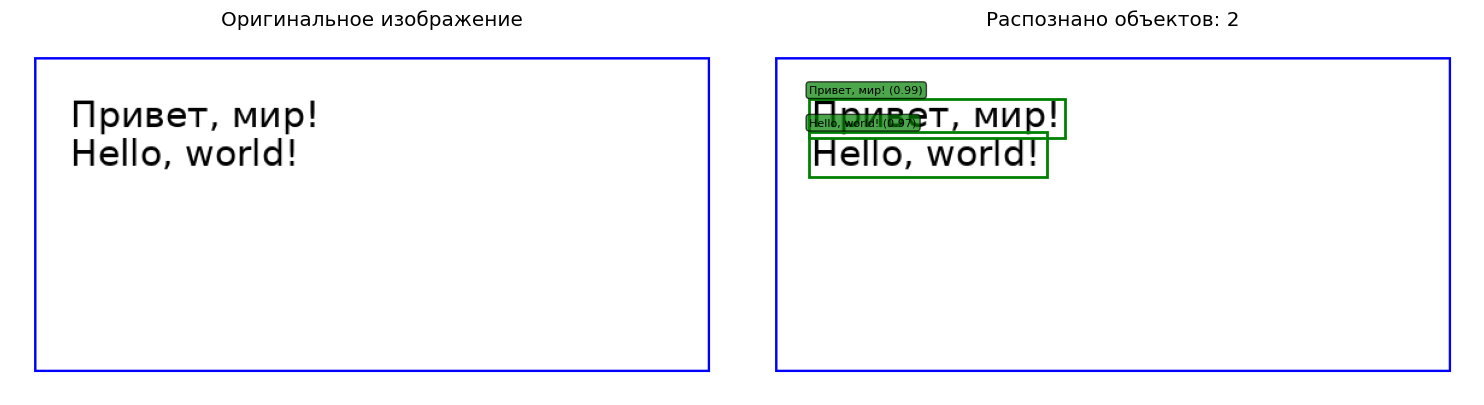

[([[48, 54], [260, 54], [260, 86], [48, 86]],
  'Привет, мир!',
  0.9869981549229956),
 ([[48, 81], [245, 81], [245, 119], [48, 119]],
  'Hello, world!',
  0.9722749432753364)]

In [4]:
# Выбираем первое тестовое изображение
image_path = test_images[0]
print(f"Изображение: {image_path}")

# Выполняем распознавание
result = ocr.recognize(image_path)

# Выводим результаты
print("\n📝 Распознанный текст:")
print(ocr.get_text(result))

# Визуализируем
ocr.visualize(image_path, result)

## 6. Анализ уверенности распознавания

Посмотрим на уровень уверенности для каждого распознанного элемента:

Статистика уверенности:
  Средняя: 97.96%
  Мин: 97.23%
  Макс: 98.70%


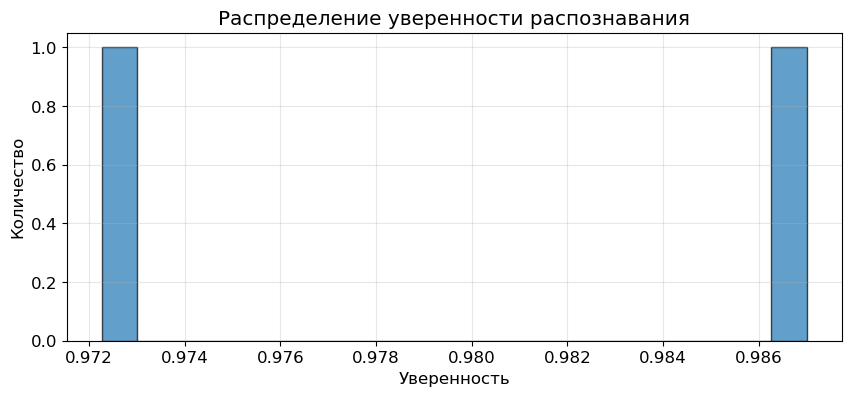


Детальные результаты:
 1. Привет, мир!                   98.70%
 2. Hello, world!                  97.23%


In [5]:
def analyze_confidence(result):
    """Анализ уверенности распознавания"""
    confidences = [item[2] for item in result]
    
    if not confidences:
        print("Нет распознанных элементов")
        return
    
    print(f"Статистика уверенности:")
    print(f"  Средняя: {np.mean(confidences):.2%}")
    print(f"  Мин: {np.min(confidences):.2%}")
    print(f"  Макс: {np.max(confidences):.2%}")
    
    # Гистограмма распределения
    plt.figure(figsize=(10, 4))
    plt.hist(confidences, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Уверенность')
    plt.ylabel('Количество')
    plt.title('Распределение уверенности распознавания')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Таблица результатов
    print("\nДетальные результаты:")
    for i, (bbox, text, conf) in enumerate(result, 1):
        print(f"{i:2}. {text:30} {conf:.2%}")

analyze_confidence(result)

## 7. Фильтрация по уверенности

Можно отфильтровать результаты с низкой уверенностью:

In [6]:
thresholds = [0.0, 0.5, 0.8, 0.9]

for thresh in thresholds:
    filtered_text = ocr.get_text(result, min_confidence=thresh)
    print(f"\nУверенность >= {thresh:.0%}:")
    if filtered_text:
        print(filtered_text)
    else:
        print("  Нет результатов")


Уверенность >= 0%:
Привет, мир!
Hello, world!

Уверенность >= 50%:
Привет, мир!
Hello, world!

Уверенность >= 80%:
Привет, мир!
Hello, world!

Уверенность >= 90%:
Привет, мир!
Hello, world!


## 8. Пакетная обработка

Обработаем все тестовые изображения одновременно:

In [7]:
def batch_process(image_list):
    """Пакетная обработка изображений"""
    results = {}
    
    for img_path in image_list:
        print(f"\n{'='*50}")
        result = ocr.recognize(img_path)
        results[img_path] = result
        
        # Сохраняем результаты
        json_path = img_path.replace('.png', '_result.json')
        ocr.save_results(result, json_path)
    
    return results

batch_results = batch_process(test_images)



📄 Анализ: test1.png
✅ Готово за 2.52 сек
💾 Результаты сохранены в data/test1_result.json


📄 Анализ: test2.png
✅ Готово за 5.75 сек
💾 Результаты сохранены в data/test2_result.json


📄 Анализ: test3.png
✅ Готово за 4.02 сек
💾 Результаты сохранены в data/test3_result.json


## 9. Работа с реальными изображениями

Загрузим и обработаем реальное изображение. Если у вас есть файл с изображением, укажите его путь:

Обработка: data/document.jpg

📄 Анализ: document.jpg
✅ Готово за 25.77 сек


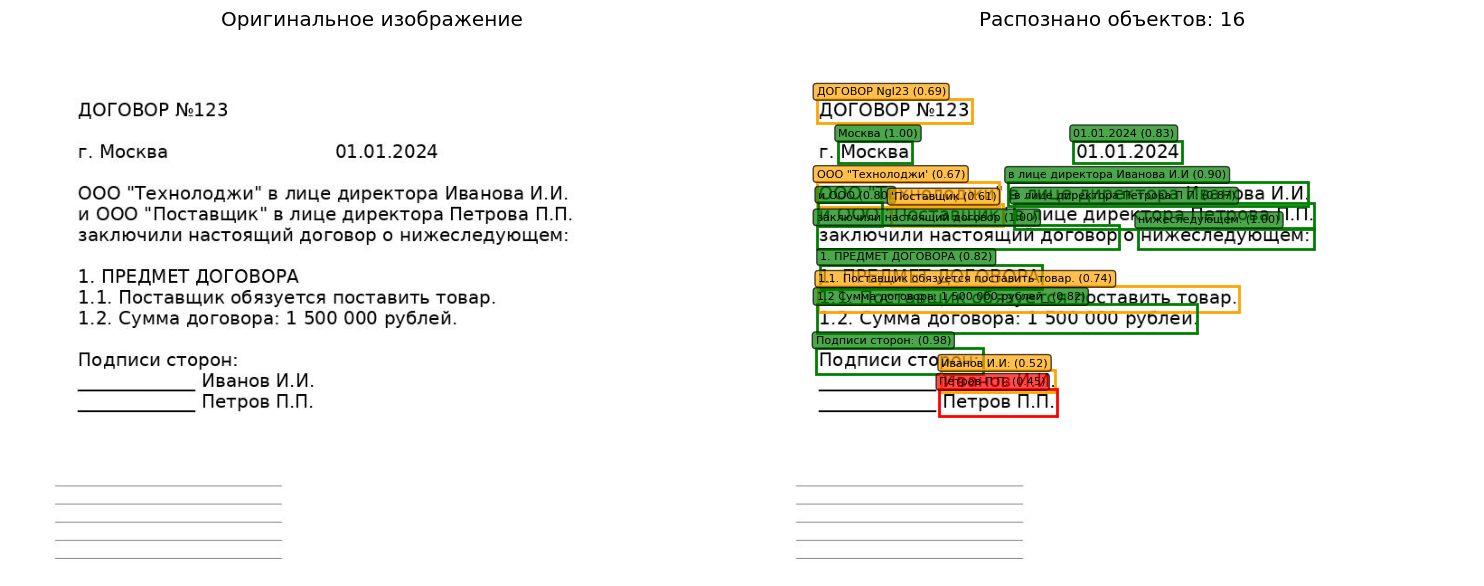


📝 Извлеченный текст:
ДОГОВОР Ngl23
Москва
01.01.2024
ООО "Технолоджи'
в лице директора Иванова И.И
и ООО
'Поставщик
в лице директора Петрова П П:
заключили настоящий договор
нижеследующем:
1. ПРЕДМЕТ ДОГОВОРА
1.1. Поставщик обязуется поставить товар.
1.2 Сумма договора: 1 500 000 рублей_
Подписи сторон:
Иванов И.И:
Петров П П:


In [8]:
# Укажите путь к вашему изображению или используйте тестовое
real_image = 'data/document.jpg'  # Замените на свой путь

if os.path.exists(real_image):
    print(f"Обработка: {real_image}")
    result_real = ocr.recognize(real_image)
    ocr.visualize(real_image, result_real)
    
    print("\n📝 Извлеченный текст:")
    print(ocr.get_text(result_real))
else:
    print("⚠️ Файл не найден. Используйте тестовое изображение.")

## 10. Экспорт в текст

In [9]:
def export_results(result, base_name):
    """Экспорт в разные форматы"""
    
    # TXT (только текст)
    with open(f"{base_name}.txt", 'w', encoding='utf-8') as f:
        f.write(ocr.get_text(result))
    


# Экспортируем результаты для первого изображения
export_results(result, "data/ocr_results")

## 11. Анализ производительности

Измерим скорость работы OCR на разных изображениях:


📄 Анализ: test1.png
✅ Готово за 3.03 сек

📄 Анализ: test1.png
✅ Готово за 3.24 сек

📄 Анализ: test1.png
✅ Готово за 3.14 сек

📄 Анализ: test2.png
✅ Готово за 4.38 сек

📄 Анализ: test2.png
✅ Готово за 4.07 сек

📄 Анализ: test2.png
✅ Готово за 4.42 сек

📄 Анализ: test3.png
✅ Готово за 3.26 сек

📄 Анализ: test3.png
✅ Готово за 3.13 сек

📄 Анализ: test3.png
✅ Готово за 3.02 сек


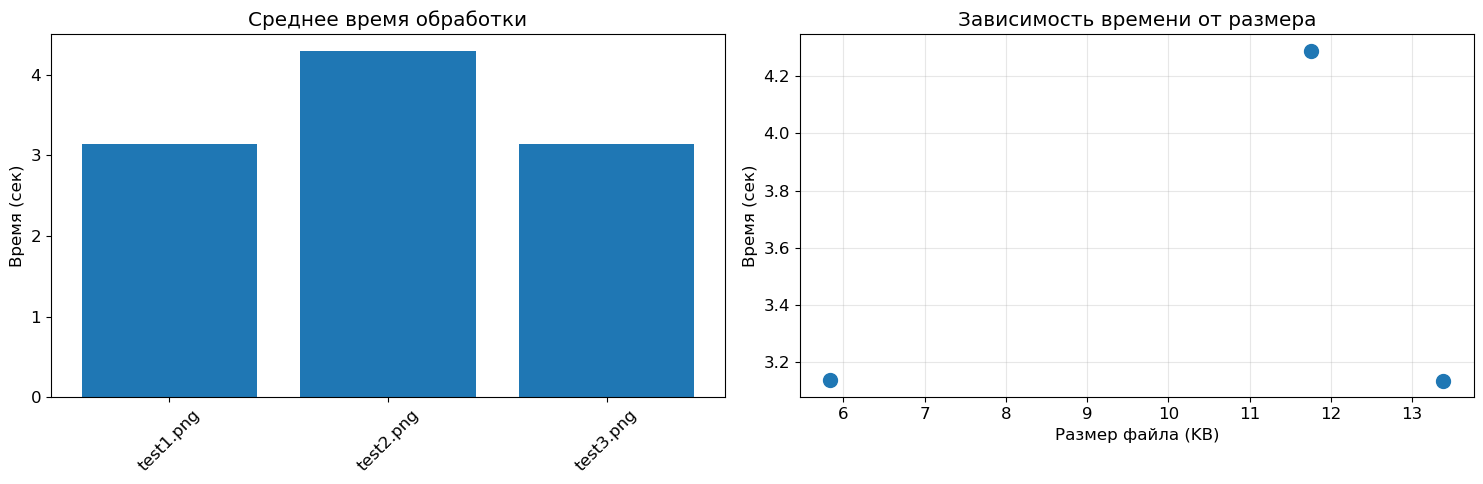


 Результаты бенчмарка:
test1.png: 3.14±0.09 сек (2 объектов)
test2.png: 4.29±0.16 сек (3 объектов)
test3.png: 3.14±0.10 сек (3 объектов)


In [10]:
def benchmark_ocr(image_paths, iterations=3):
    """Тестирование производительности"""
    
    results = []
    
    for img_path in image_paths:
        times = []
        file_size = os.path.getsize(img_path) / 1024  # KB
        
        for i in range(iterations):
            start = time.time()
            result = ocr.recognize(img_path)
            elapsed = time.time() - start
            times.append(elapsed)
        
        results.append({
            'file': os.path.basename(img_path),
            'size_kb': file_size,
            'objects': len(result),
            'avg_time': np.mean(times),
            'std_time': np.std(times)
        })
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Время обработки
    files = [r['file'] for r in results]
    times = [r['avg_time'] for r in results]
    
    ax1.bar(files, times)
    ax1.set_ylabel('Время (сек)')
    ax1.set_title('Среднее время обработки')
    ax1.tick_params(axis='x', rotation=45)
    
    # Зависимость времени от размера файла
    sizes = [r['size_kb'] for r in results]
    ax2.scatter(sizes, times, s=100)
    ax2.set_xlabel('Размер файла (KB)')
    ax2.set_ylabel('Время (сек)')
    ax2.set_title('Зависимость времени от размера')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

benchmark = benchmark_ocr(test_images)
print("\n Результаты бенчмарка:")
for r in benchmark:
    print(f"{r['file']}: {r['avg_time']:.2f}±{r['std_time']:.2f} сек ({r['objects']} объектов)")

## Задание !!!

Реализовать метрику точности распознавания OCR и проанализировать не менее 3 разных изображение!

### Полезные ссылки:
- [Документация EasyOCR](https://www.jaided.ai/easyocr/)


In [11]:
# Решение задания: метрики OCR и анализ трех изображений
import re
import unicodedata

ground_truth = {
    'data/test1.png': 'Привет, мир!\nHello, world!',
    'data/test2.png': 'DeepSeek OCR\nРаспознавание текста\nс изображений',
    'data/test3.png': 'Цифры: 1234567890\nСпецсимволы: @#$% &*()',
}

def normalize_ocr_text(text):
    text = unicodedata.normalize('NFKC', text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def levenshtein_distance(a, b):
    a, b = normalize_ocr_text(a), normalize_ocr_text(b)
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            replace_cost = previous[j - 1] + (ca != cb)
            current.append(min(insert_cost, delete_cost, replace_cost))
        previous = current
    return previous[-1]

def character_accuracy(predicted, expected):
    predicted_norm = normalize_ocr_text(predicted)
    expected_norm = normalize_ocr_text(expected)
    if not expected_norm:
        return 1.0 if not predicted_norm else 0.0
    distance = levenshtein_distance(predicted_norm, expected_norm)
    return max(0.0, 1.0 - distance / len(expected_norm))

def word_accuracy(predicted, expected):
    predicted_words = normalize_ocr_text(predicted).split()
    expected_words = normalize_ocr_text(expected).split()
    if not expected_words:
        return 1.0 if not predicted_words else 0.0
    correct = sum(p == e for p, e in zip(predicted_words, expected_words))
    return correct / len(expected_words)

def evaluate_ocr_result(result, expected_text):
    recognized_text = ocr.get_text(result)
    confidences = [item[2] for item in result]
    return {
        'recognized_text': recognized_text,
        'char_accuracy': character_accuracy(recognized_text, expected_text),
        'word_accuracy': word_accuracy(recognized_text, expected_text),
        'mean_confidence': float(np.mean(confidences)) if confidences else 0.0,
        'detected_objects': len(result),
    }

ocr_analysis = {}
for image_path, expected in ground_truth.items():
    result = batch_results.get(image_path) if 'batch_results' in globals() else None
    if result is None:
        result = ocr.recognize(image_path)

    metrics = evaluate_ocr_result(result, expected)
    ocr_analysis[image_path] = metrics

    print(f"\n{image_path}")
    print("Ожидалось:")
    print(expected)
    print("Распознано:")
    print(metrics['recognized_text'])
    print(
        f"Char accuracy: {metrics['char_accuracy']:.2%}; "
        f"Word accuracy: {metrics['word_accuracy']:.2%}; "
        f"Mean confidence: {metrics['mean_confidence']:.2%}; "
        f"Objects: {metrics['detected_objects']}"
    )

mean_char_accuracy = np.mean([m['char_accuracy'] for m in ocr_analysis.values()])
mean_word_accuracy = np.mean([m['word_accuracy'] for m in ocr_analysis.values()])
print(f"\nСредняя посимвольная точность: {mean_char_accuracy:.2%}")
print(f"Средняя пословная точность: {mean_word_accuracy:.2%}")



data/test1.png
Ожидалось:
Привет, мир!
Hello, world!
Распознано:
Привет, мир!
Hello, world!
Char accuracy: 100.00%; Word accuracy: 100.00%; Mean confidence: 97.96%; Objects: 2

data/test2.png
Ожидалось:
DeepSeek OCR
Распознавание текста
с изображений
Распознано:
DeepSeek OCR
Распознавание текста
изображений
Char accuracy: 95.74%; Word accuracy: 66.67%; Mean confidence: 96.37%; Objects: 3

data/test3.png
Ожидалось:
Цифры: 1234567890
Спецсимволы: @#$% &*()
Распознано:
Цифры: 1234567890
Спецсимволы:
#$% ^&*()
Char accuracy: 95.00%; Word accuracy: 60.00%; Mean confidence: 92.67%; Objects: 3

Средняя посимвольная точность: 96.91%
Средняя пословная точность: 75.56%
